# LSTM Hour-Ahead Bid Price Prediction
## Asset: Mainnet WETH/USDC

This notebook implements an LSTM model to predict the next hour's **Bid Price** (using `sell_price_usd` as the target). The Bid Price is the market price at which a trader can sell WETH for USDC.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Data Preparation
Target: `sell_price_usd` (The Bid Price)

In [2]:
ohlcv = pd.read_parquet('../data/mainnet_weth_usdc/curated/pool_ohlcv_hour.parquet')
edges = pd.read_parquet('../data/mainnet_weth_usdc/curated/market_edges_hour.parquet')

# Merge and sort
df = ohlcv.sort_values('timestamp').merge(edges, on='timestamp', suffixes=('', '_edge'))
df = df.set_index('timestamp')

# Target: Next hour's sell price (Bid Price)
df['target_bid'] = df['sell_price_usd'].shift(-1)
df = df.dropna()

print(f"Dataset size: {len(df)}")
df[['sell_price_usd', 'target_bid']].head()

Dataset size: 720


,sell_price_usd,target_bid
timestamp,,
2026-03-16 08:00:00+00:00,2244.330923,2244.330923
2026-03-16 09:00:00+00:00,2259.906834,2259.906834
2026-03-16 10:00:00+00:00,2277.225605,2277.225605
2026-03-16 11:00:00+00:00,2272.413377,2284.172354
2026-03-16 12:00:00+00:00,2284.172354,2284.172354


## 2. Feature Selection & Scaling
We use both the current Bid and Ask as features for better context.

In [11]:
feature_cols = ['close_usd', 'high_usd', 'low_usd', 'volume_usd', 'sell_price_usd', 'buy_price_usd', 'observed_spread_bps']
target_col = 'target_bid'

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_x = scaler_x.fit_transform(df[feature_cols])
scaled_y = scaler_y.fit_transform(df[[target_col]])

def create_sequences(x, y, window_size=24):
    X_seq, y_seq = [], []
    for i in range(len(x) - window_size):
        X_seq.append(x[i : i + window_size])
        y_seq.append(y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

window_size = 24
X, y = create_sequences(scaled_x, scaled_y, window_size)

# Time-series split
split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 3. Model Definition

In [4]:
class BidPriceLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(BidPriceLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = BidPriceLSTM(len(feature_cols), 64, 2, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 4. Training

In [9]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

num_epochs = 500
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [10/500], Loss: 0.002474
Epoch [20/500], Loss: 0.002346
Epoch [30/500], Loss: 0.002382
Epoch [40/500], Loss: 0.002277
Epoch [50/500], Loss: 0.002328
Epoch [60/500], Loss: 0.002250
Epoch [70/500], Loss: 0.002111
Epoch [80/500], Loss: 0.002145
Epoch [90/500], Loss: 0.002077
Epoch [100/500], Loss: 0.001986
Epoch [110/500], Loss: 0.001956
Epoch [120/500], Loss: 0.001954
Epoch [130/500], Loss: 0.001907
Epoch [140/500], Loss: 0.001805
Epoch [150/500], Loss: 0.001889
Epoch [160/500], Loss: 0.001763
Epoch [170/500], Loss: 0.001674
Epoch [180/500], Loss: 0.001697
Epoch [190/500], Loss: 0.001666
Epoch [200/500], Loss: 0.001755
Epoch [210/500], Loss: 0.001629
Epoch [220/500], Loss: 0.001623
Epoch [230/500], Loss: 0.001582
Epoch [240/500], Loss: 0.001569
Epoch [250/500], Loss: 0.001591
Epoch [260/500], Loss: 0.001521
Epoch [270/500], Loss: 0.001502
Epoch [280/500], Loss: 0.001512
Epoch [290/500], Loss: 0.001467
Epoch [300/500], Loss: 0.001474
Epoch [310/500], Loss: 0.001434
Epoch [320/500], 

## 5. Prediction & Results

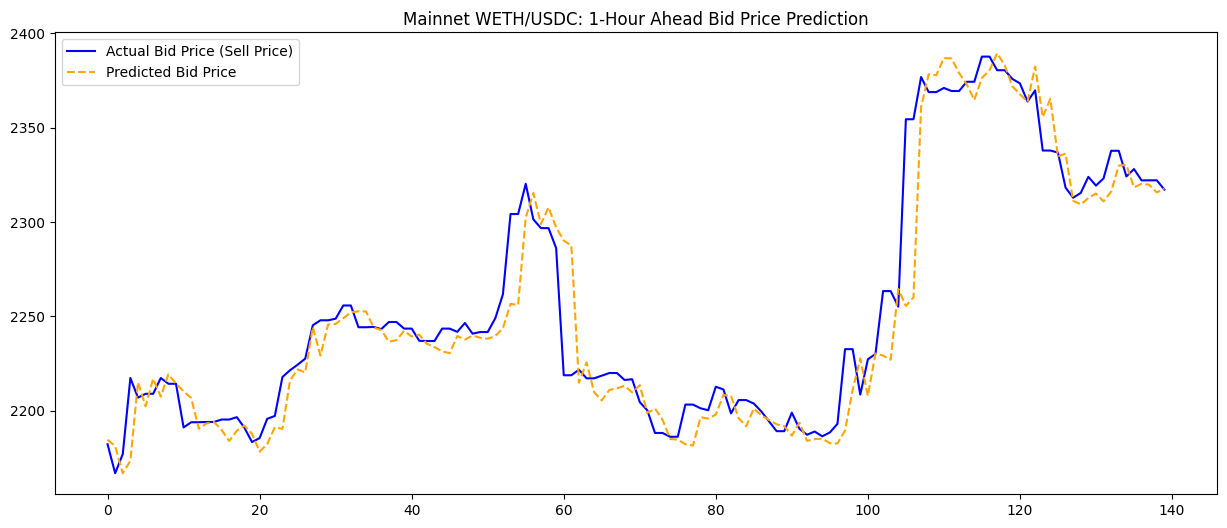

In [10]:
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    predictions = model(X_test_t).cpu().numpy()

y_test_real = scaler_y.inverse_transform(y_test)
preds_real = scaler_y.inverse_transform(predictions)

plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Actual Bid Price (Sell Price)', color='blue')
plt.plot(preds_real, label='Predicted Bid Price', color='orange', linestyle='--')
plt.title('Mainnet WETH/USDC: 1-Hour Ahead Bid Price Prediction')
plt.legend()
plt.show()